In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import sys
import os

project_root = "C:/Users/ADMIN/Downloads/timeserries_models_analysis"
sys.path.append(project_root)

from models.mlp import MLP
from models.rnn import RNNModel
from models.lstm import LSTMModel
from models.transformer import TransformerModel
from utils.preprocessing import create_sequences_xy
from utils.train import train_model
from sklearn.preprocessing import StandardScaler

In [2]:
apple_df = pd.read_csv("C:/Users/ADMIN/Downloads/timeserries_models_analysis/data/cleaned/apple_cleaned.csv")
weather_df = pd.read_csv("C:/Users/ADMIN/Downloads/timeserries_models_analysis/data/cleaned/weather_cleaned.csv")

In [3]:
apple_df.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume,price_range,price_change,return,ma_7,ma_30,volatility
0,1981-01-26,-0.458725,-0.458520,-0.458821,-0.458630,-0.443332,-0.908187,-0.382701,-0.014741,-0.577400,-0.458854,-0.459523,-0.383561
1,1981-01-27,-0.458744,-0.458538,-0.458858,-0.458667,-0.443361,-0.910958,-0.381996,-0.015849,-0.312131,-0.458833,-0.459507,-0.385371
2,1981-01-28,-0.458910,-0.458703,-0.459008,-0.458815,-0.443477,-0.897827,-0.382701,-0.014741,-1.141551,-0.458872,-0.459488,-0.383857
3,1981-01-29,-0.459076,-0.458867,-0.459176,-0.458981,-0.443609,-0.851438,-0.382701,-0.014741,-1.319459,-0.458915,-0.459465,-0.380808
4,1981-01-30,-0.459298,-0.459086,-0.459419,-0.459221,-0.443798,-0.844707,-0.381996,-0.015849,-1.958706,-0.459005,-0.459453,-0.376622
5,1981-02-02,-0.459557,-0.459342,-0.459662,-0.459461,-0.443987,-0.910760,-0.382701,-0.014741,-2.068888,-0.459137,-0.459453,-0.372748
6,1981-02-03,-0.459428,-0.459196,-0.459512,-0.459313,-0.443871,-0.924354,-0.382701,-0.013633,1.287211,-0.459246,-0.459456,-0.373163
7,1981-02-04,-0.459280,-0.459050,-0.459363,-0.459165,-0.443754,-0.898685,-0.382701,-0.013633,1.239225,-0.459323,-0.459461,-0.375224
8,1981-02-05,-0.459280,-0.459032,-0.459363,-0.459165,-0.443754,-0.957413,-0.381996,-0.013633,-0.038507,-0.459394,-0.459472,-0.378447
9,1981-02-06,-0.459261,-0.459032,-0.459344,-0.459147,-0.443740,-0.939927,-0.382701,-0.013633,0.115630,-0.459442,-0.459491,-0.381309


In [4]:
weather_df.head(10)

,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,PAR,max. PAR,Tlog,hour,day_of_week,month,hour_sin,hour_cos,month_sin,month_cos
0,2020-01-01 00:10:00,2.106838,-1.368341,-1.542018,-1.139481,0.708967,-1.081724,-1.034111,-0.732571,-1.056662,...,-0.617761,-0.614986,-1.302968,-1.661325,-0.49985,-1.597591,3.088706e-17,1.414214,0.71233,1.224489
1,2020-01-01 00:20:00,2.092340,-1.362922,-1.536704,-1.158070,0.662020,-1.079021,-1.046628,-0.721191,-1.068458,...,-0.617761,-0.614986,-1.295188,-1.661325,-0.49985,-1.597591,3.088706e-17,1.414214,0.71233,1.224489
2,2020-01-01 00:30:00,2.081189,-1.365632,-1.538033,-1.164829,0.656804,-1.080373,-1.049131,-0.719294,-1.068458,...,-0.617761,-0.614986,-1.283518,-1.661325,-0.49985,-1.597591,3.088706e-17,1.414214,0.71233,1.224489
3,2020-01-01 00:40:00,2.078958,-1.414410,-1.584526,-1.191868,0.719399,-1.103348,-1.066655,-0.738262,-1.084185,...,-0.617761,-0.614986,-1.270551,-1.661325,-0.49985,-1.597591,3.088706e-17,1.414214,0.71233,1.224489
4,2020-01-01 00:50:00,2.075613,-1.419829,-1.589840,-1.168209,0.776778,-1.104700,-1.051635,-0.751539,-1.072390,...,-0.617761,-0.614986,-1.256288,-1.661325,-0.49985,-1.597591,3.088706e-17,1.414214,0.71233,1.224489
5,2020-01-01 01:00:00,2.056655,-1.418474,-1.587183,-1.174969,0.761130,-1.104700,-1.056641,-0.747746,-1.076322,...,-0.617761,-0.614986,-1.243321,-1.516862,-0.49985,-1.597591,3.660254e-01,1.366025,0.71233,1.224489
6,2020-01-01 01:10:00,2.062231,-1.438799,-1.607109,-1.193558,0.776778,-1.114160,-1.066655,-0.753436,-1.088117,...,-0.617761,-0.614986,-1.231651,-1.516862,-0.49985,-1.597591,3.660254e-01,1.366025,0.71233,1.224489
7,2020-01-01 01:20:00,2.052194,-1.460478,-1.628363,-1.202007,0.813293,-1.123621,-1.071662,-0.762920,-1.092049,...,-0.617761,-0.614986,-1.222574,-1.516862,-0.49985,-1.597591,3.660254e-01,1.366025,0.71233,1.224489
8,2020-01-01 01:30:00,2.039927,-1.449638,-1.615079,-1.186798,0.813293,-1.118215,-1.061648,-0.762920,-1.084185,...,-0.617761,-0.614986,-1.216091,-1.516862,-0.49985,-1.597591,3.660254e-01,1.366025,0.71233,1.224489
9,2020-01-01 01:40:00,2.038812,-1.434734,-1.601795,-1.188488,0.776778,-1.112809,-1.064152,-0.753436,-1.084185,...,-0.617761,-0.614986,-1.213498,-1.516862,-0.49985,-1.597591,3.660254e-01,1.366025,0.71233,1.224489


In [5]:
scaler = StandardScaler()
apple_scaled = scaler.fit_transform(apple_df[['Close']].values)

X_apple, y_apple = create_sequences_xy(
    apple_scaled,
    apple_scaled,
    144
)

In [6]:
apple_values = apple_df[['Close']].values

target_col = 'T'
weather_features = weather_df.drop(columns=['date', target_col])
weather_target = weather_df[target_col].values

X_weather, y_weather = create_sequences_xy(
    weather_features.values,
    weather_target,
    144
)
X_apple, y_apple = create_sequences_xy(
    apple_values,
    apple_values, 
    144
)

In [7]:
print("Apple:", X_apple.shape, y_apple.shape)
print("Weather:", X_weather.shape, y_weather.shape)

Apple: (10236, 144, 1) (10236, 1)
Weather: (52560, 144, 26) (52560,)


In [8]:
# Check sequence length
print(X_apple.shape[1], X_weather.shape[1])  # should be 144

# Check feature size
print(X_apple.shape[2])     # should be 1
print(X_weather.shape[2])   # should be >1

# Check alignment
print(len(X_apple), len(y_apple))
print(len(X_weather), len(y_weather))

144 144
1
26
10236 10236
52560 52560


In [9]:
def train_test_split(X, y, split=0.8):
    idx = int(len(X) * split)
    return X[:idx], X[idx:], y[:idx], y[idx:]

def create_loader(X, y, batch_size=32):
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

def train_model(model, train_loader, test_loader, epochs=20, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, test_losses = [], []

    for epoch in range(epochs):

        # TRAIN
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            preds = model(X_batch)
            loss = criterion(preds.squeeze(), y_batch)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # TEST
        model.eval()
        test_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                preds = model(X_batch)
                loss = criterion(preds.squeeze(), y_batch)
                test_loss += loss.item()

        test_loss /= len(test_loader)
        test_losses.append(test_loss)

        print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Test={test_loss:.4f}")

    return train_losses, test_losses

def run_pipeline(X, y, model_class, name="dataset"):
    X_train, X_test, y_train, y_test = train_test_split(X, y)

    train_loader = create_loader(X_train, y_train)
    test_loader = create_loader(X_test, y_test)

    # model init
    if model_class == MLP:
        model = model_class(input_size=X.shape[2], seq_len=X.shape[1])
    elif model_class == TransformerModel:
        model = model_class(input_size=X.shape[2], seq_len=X.shape[1])
    else:
        model = model_class(input_size=X.shape[2])

    print(f"\n🚀 {model_class.__name__} on {name}\n")

    train_losses, test_losses = train_model(model, train_loader, test_loader)

    # plot
    plt.figure()
    plt.plot(train_losses, label="Train")
    plt.plot(test_losses, label="Test")
    plt.title(f"{name} - {model_class.__name__}")
    plt.legend()
    plt.show()

    return train_losses, test_losses


🚀 MLP on Apple



c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([28, 1])) that is different to the input size (torch.Size([28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1: Train=0.0333, Test=8.8433
Epoch 2: Train=0.0296, Test=7.9442
Epoch 3: Train=0.0295, Test=6.1202
Epoch 4: Train=0.0294, Test=7.9399
Epoch 5: Train=0.0293, Test=8.2172
Epoch 6: Train=0.0291, Test=7.2798
Epoch 7: Train=0.0291, Test=6.6739
Epoch 8: Train=0.0291, Test=6.6077
Epoch 9: Train=0.0290, Test=7.0989
Epoch 10: Train=0.0291, Test=7.1124
Epoch 11: Train=0.0290, Test=8.7807
Epoch 12: Train=0.0290, Test=7.8257
Epoch 13: Train=0.0290, Test=7.3151
Epoch 14: Train=0.0290, Test=8.3073
Epoch 15: Train=0.0290, Test=7.3102
Epoch 16: Train=0.0290, Test=7.2925
Epoch 17: Train=0.0290, Test=9.5129
Epoch 18: Train=0.0291, Test=7.9426
Epoch 19: Train=0.0292, Test=10.2386
Epoch 20: Train=0.0290, Test=7.0856


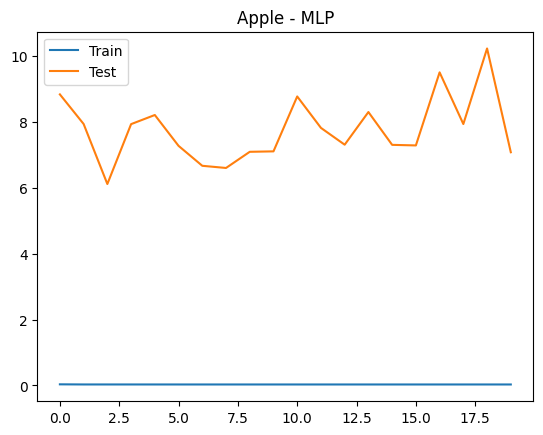


🚀 RNNModel on Apple

Epoch 1: Train=0.0313, Test=5.3076
Epoch 2: Train=0.0292, Test=5.3173
Epoch 3: Train=0.0291, Test=5.3919
Epoch 4: Train=0.0291, Test=5.4177
Epoch 5: Train=0.0291, Test=5.4707
Epoch 6: Train=0.0291, Test=5.3466
Epoch 7: Train=0.0290, Test=5.4136
Epoch 8: Train=0.0291, Test=5.3790
Epoch 9: Train=0.0290, Test=5.3381
Epoch 10: Train=0.0290, Test=5.3426
Epoch 11: Train=0.0291, Test=5.4056
Epoch 12: Train=0.0290, Test=5.4532
Epoch 13: Train=0.0291, Test=5.4063
Epoch 14: Train=0.0290, Test=5.4328
Epoch 15: Train=0.0290, Test=5.4282
Epoch 16: Train=0.0291, Test=5.3902
Epoch 17: Train=0.0290, Test=5.3989
Epoch 18: Train=0.0291, Test=5.3543
Epoch 19: Train=0.0290, Test=5.4791
Epoch 20: Train=0.0290, Test=5.4488


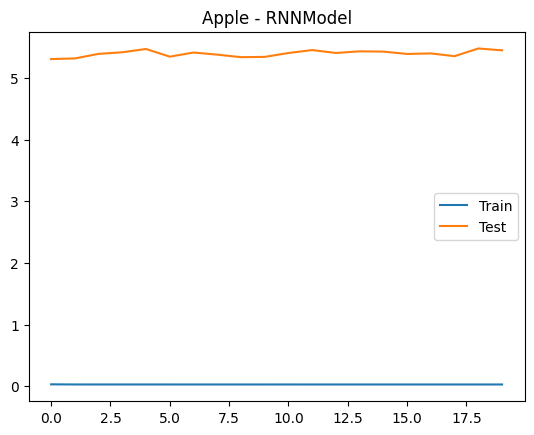


🚀 LSTMModel on Apple

Epoch 1: Train=0.0313, Test=5.3947
Epoch 2: Train=0.0291, Test=5.4985
Epoch 3: Train=0.0291, Test=5.4046
Epoch 4: Train=0.0291, Test=5.3590
Epoch 5: Train=0.0291, Test=5.4035
Epoch 6: Train=0.0291, Test=5.4607
Epoch 7: Train=0.0290, Test=5.4807
Epoch 8: Train=0.0290, Test=5.4294
Epoch 9: Train=0.0290, Test=5.4640
Epoch 10: Train=0.0290, Test=5.4054
Epoch 11: Train=0.0290, Test=5.3948
Epoch 12: Train=0.0291, Test=5.4574
Epoch 13: Train=0.0290, Test=5.4274
Epoch 14: Train=0.0290, Test=5.4073
Epoch 15: Train=0.0291, Test=5.5016
Epoch 16: Train=0.0290, Test=5.5392
Epoch 17: Train=0.0290, Test=5.4814
Epoch 18: Train=0.0290, Test=5.4739
Epoch 19: Train=0.0290, Test=5.4157
Epoch 20: Train=0.0290, Test=5.4928


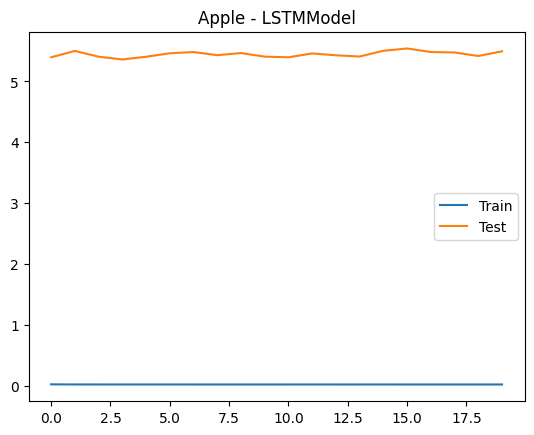


🚀 TransformerModel on Apple

Epoch 1: Train=0.0759, Test=5.7785
Epoch 2: Train=0.0311, Test=5.5981
Epoch 3: Train=0.0304, Test=5.5429
Epoch 4: Train=0.0297, Test=5.4123
Epoch 5: Train=0.0295, Test=5.7400
Epoch 6: Train=0.0299, Test=5.5117
Epoch 7: Train=0.0294, Test=5.3994
Epoch 8: Train=0.0295, Test=5.5508
Epoch 9: Train=0.0298, Test=5.4726
Epoch 10: Train=0.0297, Test=5.3806
Epoch 11: Train=0.0296, Test=5.4737
Epoch 12: Train=0.0294, Test=5.5915


KeyboardInterrupt: 

In [10]:
run_pipeline(X_apple, y_apple, MLP, "Apple")
run_pipeline(X_apple, y_apple, RNNModel, "Apple")
run_pipeline(X_apple, y_apple, LSTMModel, "Apple")
run_pipeline(X_apple, y_apple, TransformerModel, "Apple")

In [ ]:
np.mean((X_apple[:, -1, 0] - y_apple)**2)

np.float64(2.0194017738415093)